## DQN with a Target Network
### Gymnasium Discrete Lunar Lander environment.

Double DQN with Prioritized Experience Replay (PER).

Adapated from the lab code and the following references:


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import imageio
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install swig

In [ ]:
!pip install "gymnasium[box2d]"

### Define a simple Neural Network (Q-Network)

In [ ]:
# Q Network which replaces the Q table
# Input layer = number of state items
# Output layer = number of actions
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x):
        return self.fc(x)

## Define a SumTree
Paper reference for PER algorithm pseudocode: https://arxiv.org/abs/1511.05952

Implementation reference: https://github.com/Curt-Park/rainbow-is-all-you-need/blob/master/03_per.py

SumTree reference: https://github.com/openai/baselines/blob/master/baselines/common/segment_tree.py

In [ ]:
import operator


class SegmentTree(object):
    def __init__(self, capacity, operation, neutral_element):
        """Build a Segment Tree data structure.

        https://en.wikipedia.org/wiki/Segment_tree

        Can be used as regular array, but with two
        important differences:

            a) setting item's value is slightly slower.
               It is O(lg capacity) instead of O(1).
            b) user has access to an efficient ( O(log segment size) )
               `reduce` operation which reduces `operation` over
               a contiguous subsequence of items in the array.

        Parameters
        ---------
        capacity: int
            Total size of the array - must be a power of two.
        operation: lambda obj, obj -> obj
            and operation for combining elements (eg. sum, max)
            must form a mathematical group together with the set of
            possible values for array elements (i.e. be associative)
        neutral_element: obj
            neutral element for the operation above. eg. float('-inf')
            for max and 0 for sum.
        """
        assert capacity > 0 and capacity & (capacity - 1) == 0, "capacity must be positive and a power of 2."
        self._capacity = capacity
        self._value = [neutral_element for _ in range(2 * capacity)]
        self._operation = operation

    def _reduce_helper(self, start, end, node, node_start, node_end):
        if start == node_start and end == node_end:
            return self._value[node]
        mid = (node_start + node_end) // 2
        if end <= mid:
            return self._reduce_helper(start, end, 2 * node, node_start, mid)
        else:
            if mid + 1 <= start:
                return self._reduce_helper(start, end, 2 * node + 1, mid + 1, node_end)
            else:
                return self._operation(
                    self._reduce_helper(start, mid, 2 * node, node_start, mid),
                    self._reduce_helper(mid + 1, end, 2 * node + 1, mid + 1, node_end)
                )

    def reduce(self, start=0, end=None):
        """Returns result of applying `self.operation`
        to a contiguous subsequence of the array.

            self.operation(arr[start], operation(arr[start+1], operation(... arr[end])))

        Parameters
        ----------
        start: int
            beginning of the subsequence
        end: int
            end of the subsequences

        Returns
        -------
        reduced: obj
            result of reducing self.operation over the specified range of array elements.
        """
        if end is None:
            end = self._capacity
        if end < 0:
            end += self._capacity
        end -= 1
        return self._reduce_helper(start, end, 1, 0, self._capacity - 1)

    def __setitem__(self, idx, val):
        # index of the leaf
        idx += self._capacity
        self._value[idx] = val
        idx //= 2
        while idx >= 1:
            self._value[idx] = self._operation(
                self._value[2 * idx],
                self._value[2 * idx + 1]
            )
            idx //= 2

    def __getitem__(self, idx):
        assert 0 <= idx < self._capacity
        return self._value[self._capacity + idx]

In [ ]:
class SumTree(SegmentTree):
    def __init__(self, capacity):
        super(SumTree, self).__init__(
            capacity=capacity,
            operation=operator.add,
            neutral_element=0.0
        )

    def sum(self, start=0, end=None):
        """Returns arr[start] + ... + arr[end]"""
        return super(SumTree, self).reduce(start, end)

    def find_prefixsum_idx(self, prefixsum):
        """Find the highest index `i` in the array such that
            sum(arr[0] + arr[1] + ... + arr[i - i]) <= prefixsum

        if array values are probabilities, this function
        allows to sample indexes according to the discrete
        probability efficiently.

        Parameters
        ----------
        perfixsum: float
            upperbound on the sum of array prefix

        Returns
        -------
        idx: int
            highest index satisfying the prefixsum constraint
        """
        assert 0 <= prefixsum <= self.sum() + 1e-5
        idx = 1
        while idx < self._capacity:  # while non-leaf
            if self._value[2 * idx] > prefixsum:
                idx = 2 * idx
            else:
                prefixsum -= self._value[2 * idx]
                idx = 2 * idx + 1
        return idx - self._capacity

In [ ]:
# 2. The Replay Buffer
# e_t = (s_t, a_t, r_t, s_(t+1))
# Experience replay buffer = D = e1, ..., eN
class ReplayBuffer:
    def __init__(self, capacity, alpha):
        self.buffer = deque(maxlen=capacity)
        self.priority_values = SumTree(capacity)
        self.alpha = alpha
        self.p_t = 1 # During episodes, maximal priority p_t = maximum(p_i)
        self.pv_index_counter = 0 # Index counter for priority values sumTree (containing p_is)
        self.capacity = capacity
    def push(self, state, action, reward, next_state, done):
        # Store transition (S_t-1, A_t-1, R_t, gamma_t, S_t) in the buffer
        self.buffer.append((state, action, reward, next_state, done))
        # Set the transition's priority as the maximal priority p_t = max_(i<t)_p_i
        index = self.pv_index_counter
        self.priority_values[index] = self.p_t
        #self.pv_index_counter += 1 # Increment the SumTree counter
        # % to prevent buffer overflow
        # Ref: https://github.com/Curt-Park/rainbow-is-all-you-need/blob/master/08_rainbow.py
        self.pv_index_counter = (self.pv_index_counter + 1) % self.capacity
    def sample(self, batch_size, beta):
        #return random.sample(self.buffer, batch_size)
        # Prioritised Experience Replay sample method (Stochastic prioritization)
        # Sample batch_size p_is from the SumTree, and use the maximum sum (sigma_j_p_j^alpha)
        # Sampling method from paper algorithm: "To sample a minibatch of size k, the range [0, p_total] is divided equally into k ranges"
        # Splitting on probability, k = batch_size
        p_total = self.priority_values.sum()
        # Divide range [0, p_total] into k ranges, k = batch_size
        interval_size = p_total / batch_size # Do not need // as the probabilities are decimals
        # List intialisation
        priority_probabilities = []
        priority_update_indices = [] # For line 12 of the algorithm
        weights = []
        # For batch zip in training loop
        samples = []

        for k in range(batch_size):
          start_interval_range = k * interval_size
          end_interval_range = start_interval_range + interval_size
          # Uniformly sample a value from the range
          # Ref: https://www.geeksforgeeks.org/python/python-number-uniform-method/
          uniform_sample = random.uniform(start_interval_range, end_interval_range)
          # Transition corresponding to each sampled value is retrieved from the tree (from the paper)
          index = self.priority_values.find_prefixsum_idx(uniform_sample)
          priority_probability = self.priority_values[index]
          # For the training loop
          priority_probabilities.append(priority_probability)
          priority_update_indices.append(index)
          # Extract for the batch
          samples.append(self.buffer[index])

        # To unzip batch in training loop
        list_transitions = priority_probabilities

        # Calculate the Importance Sampling (IS) weights to apply during training
        # w_i = (1 / N.P(i)) ^ Beta
        # N: Buffer size
        # Beta: Anneals from 0 to 1 during training
        N = len(self.buffer)
        priority_probabilities = np.array(priority_probabilities)
        P_is = priority_probabilities / p_total # As per the equation, divide by the sum of transition probabilities
        w_is = (1 / (N * P_is)) ** beta # Compute importance-sampling weights
        # "From paper: For stability reasons, we always normalize weights by 1/ maxi wi so that they only scale the update downwards"
        w_is = w_is / w_is.max()

        #return list_transitions, w_is, priority_update_indices
        return samples, w_is, priority_update_indices

    def __len__(self):
        return len(self.buffer)
    def update(self, p_is, indices, alpha): # For a batch
      # Ref: https://stackoverflow.com/questions/43627405/understanding-getitem-method-in-python
      #priority_values[indices] = p_is
      for i, index in enumerate(indices): # Update each item in the batch sequentially
        p_i = (p_is[i]).detach().numpy()

        self.priority_values[index] = (p_i ** alpha) #+ 1) % self.capacity # Update transition priority


## train function

In [ ]:
def train_dqn(episodes=300):
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = gym.make("LunarLander-v3")


    state_dim, action_dim = env.observation_space.shape[0], env.action_space.n #env.observation_space.n, env.action_space.n
    # Initialize policy and target networks
    policy_net = QNetwork(state_dim, action_dim)
    target_net = QNetwork(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())

    # Adam optimizer for gradient descent
    optimizer = optim.Adam(policy_net.parameters(), lr=0.002) #0.001
    # Create replay buffer (for experience replay)
    capacity = 2 ** 16 #2048 # Must be even and a power of 2 for SumTree # ADDED, needs to be increased for the 700-1000 episodes

    # Hyperparameters (batch size, gamma, epsilon, epsilon decay)
    batch_size, gamma, epsilon, eps_decay = 32, 0.98, 1.0, 0.995 #0.99
    # Hyperparameters for Prioritised Experience Replay (PER)
    # Beta will increase from 0 to 1 during training
    alpha, beta, small_epsilon = 0.7, 0, 1e-6
    target_update_freq = 10

    # Extended replay buffer to include priority_values SumTree
    memory = ReplayBuffer(capacity, alpha)

    # For visualization (rewards and losses)
    rewards_history, losses_history, step_priorities, ep_priorities = [], [], [], []

    # Iterate over episodes
    for ep in range(episodes):
        # Start with new state at the beginning of each episode
        state, _ = env.reset()
        # Initialise total reward, episode losses and whether the episode is complete
        done, total_reward, ep_losses = False, 0, []
        step_priorities = []
        while not done:
            # Action selection (epsilon-greedy)
            if random.random() < epsilon:
                # Execute a random action
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0)
                    # Select the best possible action
                    action = policy_net(state_t).argmax().item()

            # Obtain the next state and reward
            next_state, reward, term, trunc, _ = env.step(action)
            # Two outcomes which result in the episode ending
            done = term or trunc
            # Update experience replay memory buffer
            # Store transition with p_i = maximal priority p_t
            memory.push(state, action, reward, next_state, term)

            # Set state to be the next state
            # Increase the total reward
            state, total_reward = next_state, total_reward + reward

            # Training step
            if len(memory) > batch_size:
                # PER sampling will use stochastic prioritisation
                # Sample transition
                batch, priority_weights, priority_indices = memory.sample(batch_size, beta)
                s_b, a_b, r_b, ns_b, d_b = zip(*batch)

                # Tensor objects
                s_t = torch.FloatTensor(np.array(s_b)) # Current state (time step = t)
                a_t = torch.LongTensor(a_b).unsqueeze(1) # Current action
                r_t = torch.FloatTensor(r_b) # Current reward
                ns_t = torch.FloatTensor(np.array(ns_b)) # Next state
                d_t = torch.FloatTensor(d_b) # Done state

                # Compute current Q values through policy network
                current_q = policy_net(s_t).gather(1, a_t).squeeze()

                # Double DQN
                # Use Policy Net to pick the best action for next state
                with torch.no_grad():
                    next_actions = policy_net(ns_t).argmax(1).unsqueeze(1)
                    # Use Target Net to evaluate that action
                    max_next_q = target_net(ns_t).gather(1, next_actions).squeeze()
                    target_q = r_t + (gamma * max_next_q * (1 - d_t))


                # Update priority values, p_is, for batch experiences (prioritisation criteria)
                p_is = abs(target_q - current_q) + small_epsilon # Compute TD error
                memory.update(p_is, priority_indices, alpha)

                # Execute gradient descent step
                # Mean Square Error loss using the current Q value and target Q value
                # Loss uses weights and element-wise MSE
                # Ref: https://github.com/Curt-Park/rainbow-is-all-you-need/blob/master/03_per.py
                # Ref: https://docs.pytorch.org/docs/2.12/generated/torch.nn.MSELoss.html
                elementwise_loss = nn.MSELoss(reduction='none')(current_q, target_q)
                priority_weights = torch.FloatTensor(priority_weights).to(device)
                loss = torch.mean(elementwise_loss * priority_weights)

                # Neural network backpropagation and update the network weights
                optimizer.zero_grad(); loss.backward(); optimizer.step() # Update weights theta and reset gradient to 0
                # For graph plotting
                ep_losses.append(loss.item())
                # For priority distribution
                p_is = p_is.detach().cpu().tolist()
                step_priorities.extend(p_is)
        # Update rewards list for graph plotting
        rewards_history.append(total_reward)
        # Update losses list for graph plotting
        if ep_losses:
            losses_history.append(np.mean(ep_losses))
        if ep % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())
        ep_priorities.append(max(step_priorities))
        # Epsilon decay
        epsilon = max(0.01, epsilon * eps_decay) #0.01
        print("Episode: ", ep, " | Total reward: ", total_reward ," | Epsilon: ", epsilon, " | Beta: ", beta)
        # Anneal beta from 0 to 1 across episodes
        beta = min(1.0, beta + 0.003)
    # Plot graphs
    plot_results(rewards_history, losses_history, policy_net, state_dim, ep_priorities)
    return policy_net

In [ ]:
def plot_results(rewards, losses, net, state_dim, ep_priorities):
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

    # Save graph arrays for later loading
    rewards_path = '/content/drive/MyDrive/RL_CW/graphs/E2_rewards.npy'
    losses_path = '/content/drive/MyDrive/RL_CW/graphs/E2_losses.npy'
    priorities_path = '/content/drive/MyDrive/RL_CW/graphs/E2_priorities.npy'

    # Save the numpy arrays
    np.save(rewards_path, np.array(rewards))
    np.save(losses_path, np.array(losses))
    np.save(priorities_path, np.array(ep_priorities))

    #print(ep_priorities)

    # Success Rate (Moving Average)
    window = 50
    #print("rewards", rewards)
    mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax1.plot(mov_avg, color='blue')
    ax1.set_title(f"Success Rate ({window} Episode Moving Average)")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("Reward")

    # Loss
    ax2.plot(losses, color='red', alpha=0.5)
    ax2.set_title("Training Loss")
    ax2.set_xlabel("Episode"); ax2.set_ylabel("Loss")

    sns.histplot(ep_priorities, color='blue', bins=30,ax=ax3)
    ax3.set_title("Maximum Priority Distribution")
    ax3.set_xlabel("Maximum Priority");ax3.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [ ]:
# GIF Generation for LunarLander
def save_lander_gif(policy_net, filename="lunar_lander_dqn.gif"):
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    state, _ = env.reset()
    frames, done = [], False

    while not done:
        frames.append(env.render())
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad(): # No training
            action = policy_net(state_t).argmax().item()
        state, _, term, trunc, _ = env.step(action)
        done = term or trunc

    imageio.mimsave(filename, frames, fps=30, loop=0)
    env.close()
    print(f"Visualized lander saved to {filename}")

## Viusalization ...

Episode:  0  | Total reward:  -63.235410455285404  | Epsilon:  0.995  | Beta:  0
Episode:  1  | Total reward:  -320.8672368977335  | Epsilon:  0.990025  | Beta:  0.003
Episode:  2  | Total reward:  -61.01889392467301  | Epsilon:  0.985074875  | Beta:  0.006
Episode:  3  | Total reward:  -204.5930613592805  | Epsilon:  0.9801495006250001  | Beta:  0.009000000000000001
Episode:  4  | Total reward:  -241.14443366344778  | Epsilon:  0.9752487531218751  | Beta:  0.012
Episode:  5  | Total reward:  -133.03736139870696  | Epsilon:  0.9703725093562657  | Beta:  0.015
Episode:  6  | Total reward:  -201.67436964230126  | Epsilon:  0.9655206468094844  | Beta:  0.018
Episode:  7  | Total reward:  -98.00473909332646  | Epsilon:  0.960693043575437  | Beta:  0.020999999999999998
Episode:  8  | Total reward:  -277.3526073531142  | Epsilon:  0.9558895783575597  | Beta:  0.023999999999999997
Episode:  9  | Total reward:  -138.0546681680996  | Epsilon:  0.9511101304657719  | Beta:  0.026999999999999996
E

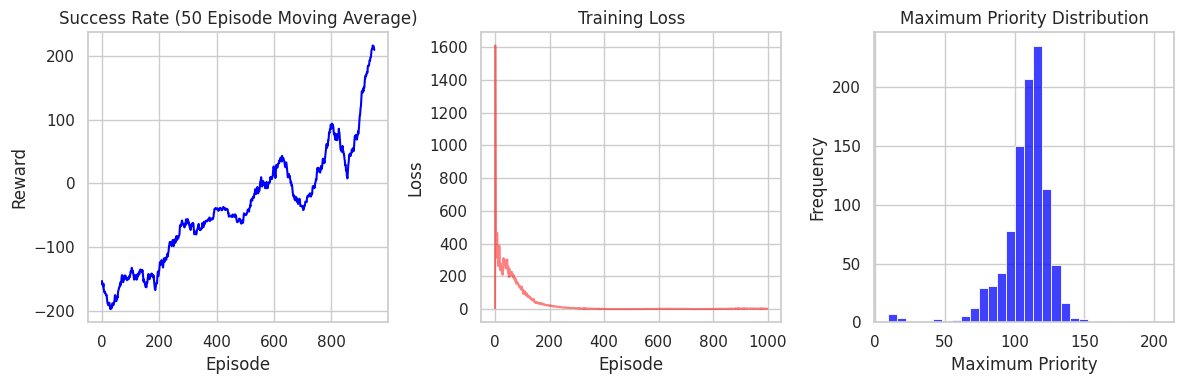

In [ ]:
trained_dqn = train_dqn(episodes=1000)

In [ ]:
save_lander_gif(trained_dqn)

Visualized lander saved to lunar_lander_dqn.gif


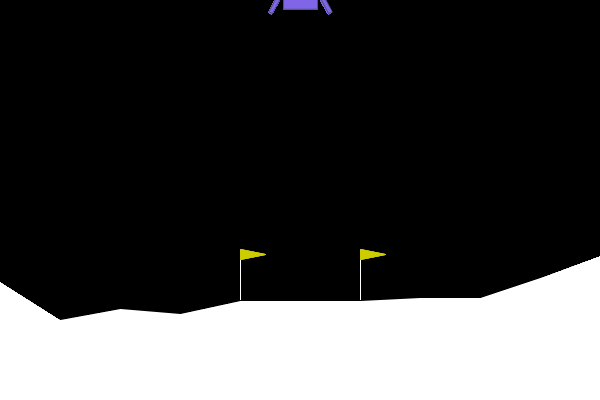

In [ ]:
from IPython.display import Image
Image(filename="lunar_lander_dqn.gif")

In [ ]:
from google.colab import files
files.download("lunar_lander_dqn.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>